The efficiency associated with the $S1$ multiplicity cut depends in real time on the general noise of the detector (mostly from the electronics).
<br>
Thus, monitoring the $S1$ multiplicity constitutes an importan task in the efficiency analysis. 

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import crudo

from iminuit import Minuit
from iminuit.cost import LeastSquares
from invisible_cities.core.core_functions import in_range
from invisible_cities.reco.corrections import apply_all_correction, read_maps
from invisible_cities.types.symbols import NormMethod
from invisible_cities.types.symbols import NormStrategy
from joblib import delayed, Parallel
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from PIL import Image
import scipy
import yaml

# Styling Plot
crudo.pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Configuration

In [4]:
# --- NOTEBOOK PARAMETERS --- #
RUN_NUMBER = 15737
VERSION_TAG = "LPR_p2_v3"
# ANA_OPTIONS =  ['data']
# ANA_INFO = {opt:{} for opt in ANA_OPTIONS }

# --- LOAD CONFIGURATIONS --- #
CONFIG_FILE = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Universal/configs/low_bckg_analysis_config.yaml'
try:
    with open(CONFIG_FILE, 'r') as f:
        all_configs = yaml.safe_load(f)
except FileNotFoundError:
    raise FileNotFoundError(f"Configuration file '{CONFIG_FILE}' not found. Please check the path and try again.")

if VERSION_TAG not in all_configs:
    raise ValueError(f"Version tag '{VERSION_TAG}' not found in the configuration file. Available tags: {list(all_configs.keys())}")

# Set up the configurations
common_config = all_configs['common']
ana_config    = all_configs[VERSION_TAG]

# --- LOAD DATA --- #
input_dir = common_config['input_dir'] + 'runs/'
filepath = next((os.path.join(input_dir, f) for f in os.listdir(input_dir) if str(RUN_NUMBER) in f and VERSION_TAG in f), None)
print(f"Loading data from: {filepath}")
FILE_DF = pd.read_hdf(filepath, key=common_config['evt_key'])

# --- HE SCALE --- #
HE_SCALE = ana_config['data']['he_scale']
TRG2_THRESHOLD = 0.5

Loading data from: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/processed_run_15737_LPR_p2_v3_events.h5


In [5]:
FILE_DF

,event,nS1,nS2,old_n_hits,time,S1e,S1w,S1h,S1t,S2e,...,X_bary,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max
0,596,1,1,7507,1.759250e+09,1390.610352,350.0,246.651306,47750.0,906339.750000,...,215.529927,165.032834,1185.550778,-482.625,490.025,-479.925,492.725,1168.349013,1205.836166,499.423574
1,645,27,1,3840,1.759250e+09,56.800293,650.0,2.604467,8200.0,245202.781250,...,-119.203772,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969
2,645,27,1,3840,1.759250e+09,79.898323,925.0,2.707778,36625.0,245202.781250,...,-119.203772,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969
3,645,27,1,3840,1.759250e+09,60.654854,675.0,2.833246,103575.0,245202.781250,...,-119.203772,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969
4,645,27,1,3840,1.759250e+09,53.976631,600.0,2.802793,122350.0,245202.781250,...,-119.203772,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128756,1790530,2,3,2383,1.759302e+09,1401.136353,750.0,61.940659,44725.0,7890.836914,...,-204.695629,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353
128757,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,5151.856445,...,-204.695629,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353
128758,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,352854.281250,...,-204.695629,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353
128759,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,7890.836914,...,-204.695629,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353


In [ ]:
# ----- S1e Cut & Correction ----- #
test_df = FILE_DF.copy()
# nS1 <= 1 (NO-Polike)
s1_mask = (test_df['nS1'] == 0) | ((test_df['nS1'] == 1) & (test_df['S1h'] >= M_NOPOLIKE * test_df['S1e'] + B_NOPOLIKE))
test_df = test_df[s1_mask]
test_df['DT'] = (test_df['S2t'] - test_df['S1t']) / 1e3
# local_evt_counter[cut_names[3]] = df_soph['event'].nunique()

# S1e Correction
test_df = crudo.ef.correct_S1e(test_df, CV_FIT, DT_CATH, output_column='S1e_corr')     # Based on alpha analysis
print(test_df.event.nunique())

12325


In [7]:
test_df

,event,nS1,nS2,old_n_hits,time,S1e,S1w,S1h,S1t,S2e,...,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,DT,S1e_corr
0,596,1,1,7507,1.759250e+09,1390.610352,350.0,246.651306,47750.0,9.063398e+05,...,1185.550778,-482.625,490.025,-479.925,492.725,1168.349013,1205.836166,499.423574,1370.737500,1380.192674
97,2829,1,2,8550,1.759250e+09,1061.939453,350.0,179.026657,1047700.0,9.547769e+05,...,313.682277,-482.625,490.025,-479.925,492.725,303.793298,326.972811,507.172462,362.786250,1657.529091
98,2829,1,2,8550,1.759250e+09,1061.939453,350.0,179.026657,1047700.0,4.272669e+03,...,313.682277,-482.625,490.025,-479.925,492.725,303.793298,326.972811,507.172462,759.813125,1352.470140
154,5013,1,1,3231,1.759250e+09,1178.166016,675.0,208.488998,41550.0,5.014703e+05,...,1188.469778,-420.425,490.025,-448.825,430.525,1171.992284,1209.448839,500.123641,1372.940000,1168.410201
233,5363,1,1,8274,1.759250e+09,1395.159790,650.0,242.132187,49450.0,9.836937e+05,...,1184.178051,-482.625,490.025,-479.925,492.725,1164.314112,1205.276403,494.520987,1369.038375,1385.558501
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128750,1789053,1,1,7630,1.759302e+09,1407.644653,650.0,251.366013,49450.0,9.181305e+05,...,1184.787879,-482.625,474.475,-479.925,492.725,1163.695637,1204.315713,506.672815,1370.037875,1397.452557
128751,1789270,1,1,8047,1.759302e+09,1378.959717,900.0,233.034393,49025.0,9.645358e+05,...,1184.800715,-482.625,490.025,-479.925,492.725,1164.829003,1209.152468,500.123641,1370.461375,1368.765855
128752,1790145,0,1,7346,1.759302e+09,NaN,NaN,NaN,NaN,8.981901e+05,...,40.530389,-482.625,490.025,-479.925,492.725,19.056382,63.463104,498.160472,NaN,NaN
128753,1790215,1,1,9115,1.759302e+09,1307.270386,675.0,222.353699,377450.0,1.044777e+06,...,897.973101,-482.625,490.025,-479.925,492.725,881.601513,915.386142,496.083225,1038.037375,1474.721202


In [ ]:
proof_df = pd.read_hdf('/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/processed_run_15737_LPR_p2_v2_events.h5', key='Events')
proof_df

## Function

In [ ]:
# all_processed_df = []

# for f in LIST_FILE:
#     print(f"--- Merging File: {os.path.basename(f)} ---")
#     dataframe = pd.read_hdf(f, key='Events')
#     all_processed_df.append(dataframe)

# MERGED_DF = pd.concat(all_processed_df, ignore_index=True)

In [ ]:
# def process_file(filepath, kr_path):
    """
    Processes a single file containing NEXT-100 background data, applying a series of cuts and corrections 
    to prepare the data for further analysis. 
    Parameters:
    -----------
        filepath : str
            Path to the input HDF5 file containing Dorothea and Sophronia data.
        kr_path : str
            Path to the Krypton map file used for energy corrections.
        kr_city : str
            The city corresponding to the Krypton map (e.g., 'icaros', 'zemrude') to apply the correct energy correction.   
        cut_names : list of str, optional
            List of cut names to track the number of events passing each cut. Defaults to CUT_NAMES.
    Returns:
    --------
        df_event_peak : pandas.DataFrame
            Dataframe containing the processed data aggregated to the event-peak level.
        df_soph_final : pandas.DataFrame
            Dataframe containing the final hits-level data with relevant columns.
        local_evt_counter : dict
            Dictionary containing the count of events passing each cut.
    Notes:
    ------
    - The function performs the following steps:
        1. Loads Dorothea and Sophronia data from the input file.
        2. Computes the Z position using drift velocity and removes events with Z <= 0.
        3. Applies energy corrections using a Krypton map.
        4. Applies S1e cuts and corrections based on alpha analysis.
        5. Deals with spurious hits using a clustering function.
        6. Aggregates the data to event-peak level for further analysis.
    - If an error occurs during processing, the function returns empty dataframes and a dictionary of zeros 
      to ensure robustness.
    """
    filename = os.path.basename(filepath)
    print(f"→ Processing file: {filename}")
    
    try:
        # ----- Load Dorothea & Sophronia ----- #
        df_doro = pd.read_hdf(filepath, key=DORO_KEY).loc[:, DORO_COLUMNS]
        df_soph = pd.read_hdf(filepath, key=SOPH_KEY).loc[:, SOPH_COLUMNS]
        # Compute Z in [mm]
        df_soph.rename(columns={'Z': 'DT'}, inplace=True)   # Rename Z to DT for consistency
        df_soph['Z'] = df_soph['DT'] * V_DRIFT              # Compute real Z position: using the drift velocity
       
        print('Step 01 done')

        # ----- Deal with Spurious Hits ----- #
        df_soph = CLUSTER_FUNCTION(df_soph)
        df_soph = crudo.tf.deal_spurious_hits(df_soph, energy_column='E', output_column='E_hit_pe')
        clean_evt_ids = df_soph['event'].unique()
        df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=clean_evt_ids)

        print('Step 02 done')

        # ----- Removing Z <= 0 ----- #
        events_with_negative_z_hits = df_soph.loc[df_soph['Z'] < 0, 'event'].unique()
        events_with_positive_z_hits = np.setdiff1d(clean_evt_ids, events_with_negative_z_hits)
        df_doro, df_soph = crudo.dm.apply_cut_and_update(df_doro, df_soph, event_ids=events_with_positive_z_hits)

        print('Step 03 done')

        # ----- Energy Correction ----- #
        df_soph = crudo.ef.correct_energy_by_kr_map( df_soph
                                                   , kr_path
                                                   , norm_method = NormMethod.median_anode
                                                   , city = 'zemrude'
                                                   , mev_units = True
                                                   , energy_col = 'E_hit_pe'
                                                   , output_col ='Ec' )

        print('Step 04 done')

        # ----- Data @ Event/Peak-Level ----- #
        # Now, store just the relevant columns in final Sophronia dataframe
        df_soph = df_soph.loc[:, FINAL_SOPH_COLUMNS].copy()

        # --- Event-Level Simple Aggregations ---
        # These are properties that are constant per event or where a simple operation is sufficient
        simple_agg_dict = {col: (col, 'first') for col in EVENT_LEVEL_COLS}
        simple_agg_dict['time'] = ('time', 'mean')  # Special case for 'time'
        doro_info_df = df_doro.groupby('event').agg(**simple_agg_dict).reset_index()

        # --- Add S1 and S2 Peaks Information ---
        peaks_info_df = df_doro[['event'] + S1_PULSE_COLS].copy()
        doro_info_df  = doro_info_df.merge(peaks_info_df, on='event', how='left')

        # doro_info_df = crudo.dm.summarize_dorothea_info(df_doro, event_level_cols=EVENT_LEVEL_COLS)


        soph_info_df = df_soph.groupby('event').agg(
            E_evt     = ('Ec', 'sum')
        )

        df_event_peak = pd.merge(doro_info_df, soph_info_df, on='event', how='left')
        # # Finally, aggregate to event-peak level
        # df_event_peak = crudo.dm.aggregate_to_event_peak_level(df_doro, df_soph, event_level_cols=EVENT_LEVEL_COLS, energy_column='Ec')
        
    except Exception as e:
        print(f"   Failed to process file {filename}. Error: {e}", file=sys.stderr)
        # Return a dictionary of zeros on failure to not affect the final sum
        return pd.DataFrame(), pd.DataFrame()

    return df_soph, df_event_peak

# S1 Multiplicity

In [12]:
FILE_DF

,event,nS1,nS2,old_n_hits,time,S1e,S1e_corr,S1w,S1h,S1t,...,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,E_final
0,596,1,1,7507,1.759250e+09,1390.610352,1380.192650,350.0,246.651306,47750.0,...,165.032834,1185.550778,-482.625,490.025,-479.925,492.725,1168.349013,1205.836166,499.423574,4.821764
1,2829,1,2,8550,1.759250e+09,1061.939453,1657.529086,350.0,179.026657,1047700.0,...,-187.225021,313.682277,-482.625,490.025,-479.925,492.725,303.793298,326.972811,507.172462,5.420296
2,2829,1,2,8550,1.759250e+09,1061.939453,1352.470111,350.0,179.026657,1047700.0,...,-187.225021,313.682277,-482.625,490.025,-479.925,492.725,303.793298,326.972811,507.172462,5.420296
3,5013,1,1,3231,1.759250e+09,1178.166016,1168.410174,675.0,208.488998,41550.0,...,157.499431,1188.469778,-420.425,490.025,-448.825,430.525,1171.992284,1209.448839,500.123641,2.924112
4,5363,1,1,8274,1.759250e+09,1395.159790,1385.558463,650.0,242.132187,49450.0,...,-100.506325,1184.178051,-482.625,490.025,-479.925,492.725,1164.314112,1205.276403,494.520987,5.030869
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13979,1789053,1,1,7630,1.759302e+09,1407.644653,1397.452512,650.0,251.366013,49450.0,...,255.607453,1184.787879,-482.625,474.475,-479.925,492.725,1163.695637,1204.315713,506.672815,4.894130
13980,1789270,1,1,8047,1.759302e+09,1378.959717,1368.765830,900.0,233.034393,49025.0,...,157.430957,1184.800715,-482.625,490.025,-479.925,492.725,1164.829003,1209.152468,500.123641,5.008883
13981,1790145,0,1,7346,1.759302e+09,NaN,NaN,NaN,NaN,NaN,...,111.484184,40.530389,-482.625,490.025,-479.925,492.725,19.056382,63.463104,498.160472,4.403225
13982,1790215,1,1,9115,1.759302e+09,1307.270386,1474.721141,675.0,222.353699,377450.0,...,-139.808238,897.973101,-482.625,490.025,-479.925,492.725,881.601513,915.386142,496.083225,5.361969


In [6]:
# --- HE Scale --- #
FILE_DF = crudo.ef.he_scale_converter(FILE_DF, HE_SCALE['m'], HE_SCALE['b'], input_column='E_evt', output_column='E_final')
HIGH_DF = FILE_DF[FILE_DF['E_final'] >= TRG2_THRESHOLD].copy()
LOW_DF  = FILE_DF[FILE_DF['E_final'] < TRG2_THRESHOLD].copy()

In [ ]:
def calculate_hourly_stats(df: pd.DataFrame, variable: str, stat: str='first', event_column: str='event') -> pd.DataFrame: #AGREGAR NUEVA COLUMNAAA
    """
    Calculate hourly statistics for a given variable in a DataFrame.

    Parameters:
    -----------
    df : pd.DataFrame
        Input DataFrame containing the data.
    variable : str
        Column name of the variable to calculate statistics for.
    stat : str, optional
        Aggregation method for the variable (default is 'first').
    event_column : str, optional
        Column name representing event identifiers (default is 'event').

    Returns:
    --------
    pd.DataFrame
        DataFrame with hourly time centers, calculated means, and standard errors.
    """
    evt_df = df.groupby(event_column).agg(var=(variable, stat), time=('time', 'mean')).reset_index()

    # Time chunks
    time_in_hours = (evt_df['time'] - evt_df['time'].min()) / 3600  # Convert time to hours
    time_bins = np.arange(0, time_in_hours.max() + 1.001, 1)        # One bin per hour
    time_groups = pd.cut(time_in_hours, bins=time_bins, right=False)

    # Average nS1 multiplicity per event per hour
    hourly_stats = evt_df.groupby(time_groups)['var'].agg(['median', 'sem']).reset_index()
    hourly_stats = hourly_stats.dropna()

    # Representative points for each time bin (in EPOCH time)
    time_centers = [evt_df['time'].min() + (3600 * interval.mid) for interval in hourly_stats['time'].values]

    # Store results
    return pd.DataFrame({'time_cv': time_centers,
                         f'{variable}_cv': hourly_stats['median'].values,
                         f'{variable}_err': hourly_stats['sem'].values})

In [22]:
HIGH_DF

,event,nS1,nS2,old_n_hits,time,S1e,S1w,S1h,S1t,S2e,...,Y_bary,Z_bary,X_min,X_max,Y_min,Y_max,Z_min,Z_max,R_max,E_final
0,596,1,1,7507,1.759250e+09,1390.610352,350.0,246.651306,47750.0,906339.750000,...,165.032834,1185.550778,-482.625,490.025,-479.925,492.725,1168.349013,1205.836166,499.423574,4.821764
1,645,27,1,3840,1.759250e+09,56.800293,650.0,2.604467,8200.0,245202.781250,...,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969,0.693983
2,645,27,1,3840,1.759250e+09,79.898323,925.0,2.707778,36625.0,245202.781250,...,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969,0.693983
3,645,27,1,3840,1.759250e+09,60.654854,675.0,2.833246,103575.0,245202.781250,...,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969,0.693983
4,645,27,1,3840,1.759250e+09,53.976631,600.0,2.802793,122350.0,245202.781250,...,-93.959742,1204.353436,-482.625,490.025,-479.925,492.725,1198.707701,1204.369234,492.737969,0.693983
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128756,1790530,2,3,2383,1.759302e+09,1401.136353,750.0,61.940659,44725.0,7890.836914,...,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,1.919743
128757,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,5151.856445,...,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,1.919743
128758,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,352854.281250,...,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,1.919743
128759,1790530,2,3,2383,1.759302e+09,41.109947,1200.0,2.425249,84250.0,7890.836914,...,286.526952,1209.158726,-404.875,273.325,-417.725,477.175,1165.169164,2347.797705,495.426353,1.919743


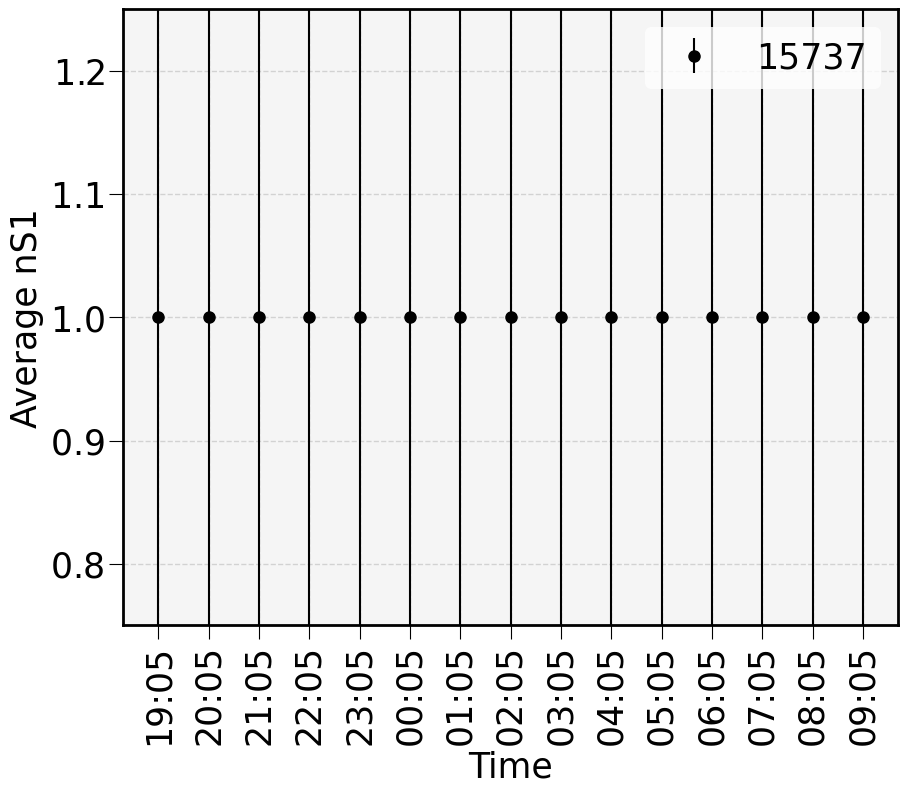

In [31]:
mult_df = calculate_hourly_stats(HIGH_DF, variable='nS1', stat='first')

plt.errorbar( mult_df['time_cv'], mult_df['nS1_cv'], yerr=mult_df['nS1_err']
            , fmt='o', c='black', ecolor='black', elinewidth=1.5, label=RUN_NUMBER)

x_labels = [crudo.ut.epoch_converter(t, h=True) for t in mult_df['time_cv']]
plt.xticks(mult_df['time_cv'], x_labels, rotation=90)
plt.xlabel('Time')
plt.ylabel('Average nS1')
plt.ylim(mult_df['nS1_cv'].min()*0.75, mult_df['nS1_cv'].max()*1.25)
plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

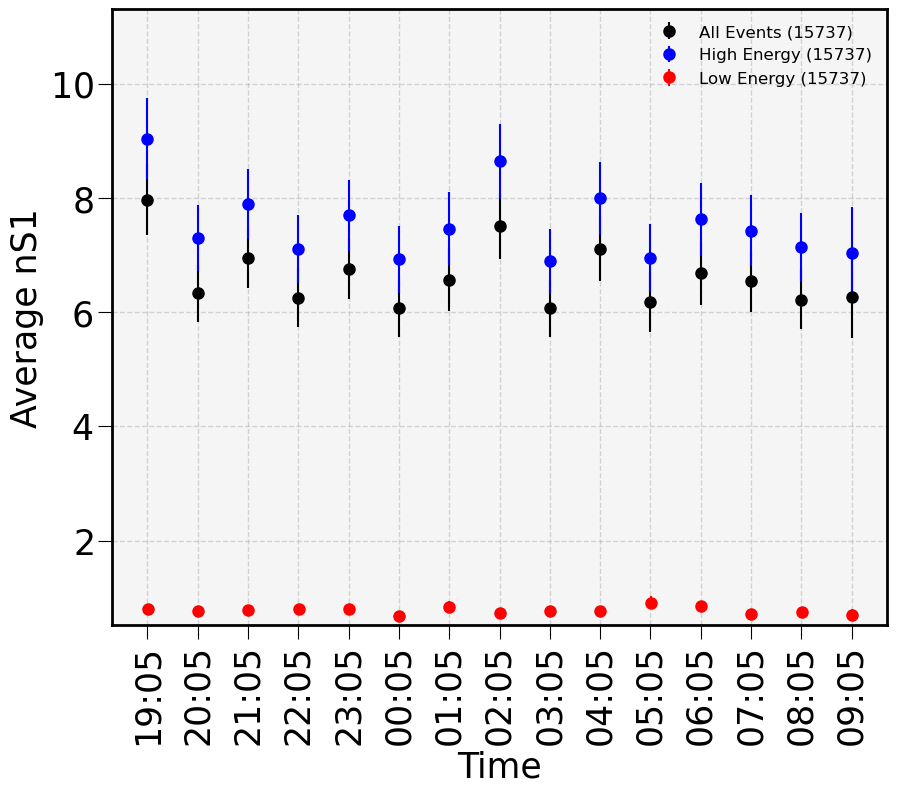

In [8]:
# Calcular estadísticas para cada DataFrame
mult_file_df = calculate_hourly_stats(FILE_DF)
mult_high_df = calculate_hourly_stats(HIGH_DF)
mult_low_Df = calculate_hourly_stats(LOW_DF)

plt.errorbar(mult_file_df['time_cv'], mult_file_df['nS1_cv'], yerr=mult_file_df['nS1_err'],
             fmt='o', c='black', ecolor='black', elinewidth=1.5, label=f"All Events ({RUN_NUMBER})")
plt.errorbar(mult_high_df['time_cv'], mult_high_df['nS1_cv'], yerr=mult_high_df['nS1_err'],
             fmt='o', c='blue', ecolor='blue', elinewidth=1.5, label=f"High Energy ({RUN_NUMBER})")
plt.errorbar(mult_low_Df['time_cv'], mult_low_Df['nS1_cv'], yerr=mult_low_Df['nS1_err'],
             fmt='o', c='red', ecolor='red', elinewidth=1.5, label=f"Low Energy ({RUN_NUMBER})")

x_labels = [crudo.ut.epoch_converter(t, h=True) for t in mult_file_df['time_cv']]
plt.xticks(mult_file_df['time_cv'], x_labels, rotation=90)
plt.xlabel('Time')
plt.ylabel('Average nS1')
plt.ylim(min(mult_low_Df['nS1_cv'].min(), mult_file_df['nS1_cv'].min(), mult_high_df['nS1_cv'].min()) * 0.75,
         max(mult_low_Df['nS1_cv'].max(), mult_file_df['nS1_cv'].max(), mult_high_df['nS1_cv'].max()) * 1.25)
plt.legend(fontsize=12, facecolor='None')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()

In [13]:
evt_df = HIGH_DF.groupby('event').agg( nS1=('nS1', 'first')
                                     , time=('time', 'mean')).reset_index()

# Time chunks
time_in_hours  = (evt_df['time'] - evt_df['time'].min()) / 3600     # Convert time to hours
time_bins = np.arange(0, time_in_hours.max() + 1.001, 1)            # One bin per hour
time_groups = pd.cut(time_in_hours, bins=time_bins, right=False)

# Average nS1 multiplicity per event per hour
hourly_stats = evt_df.groupby(time_groups)['nS1'].agg(['mean', 'sem']).reset_index()
hourly_stats = hourly_stats.dropna()

# Representative points for each time bin (in EPOCH time)
time_centers = [evt_df['time'].min() + (3600 * interval.mid) for interval in hourly_stats['time'].values]

# Store results
mult_df = pd.DataFrame({ 'time_cv' : time_centers
                       , 'nS1_cv'  : hourly_stats['mean'].values
                       , 'nS1_err' : hourly_stats['sem'].values  })

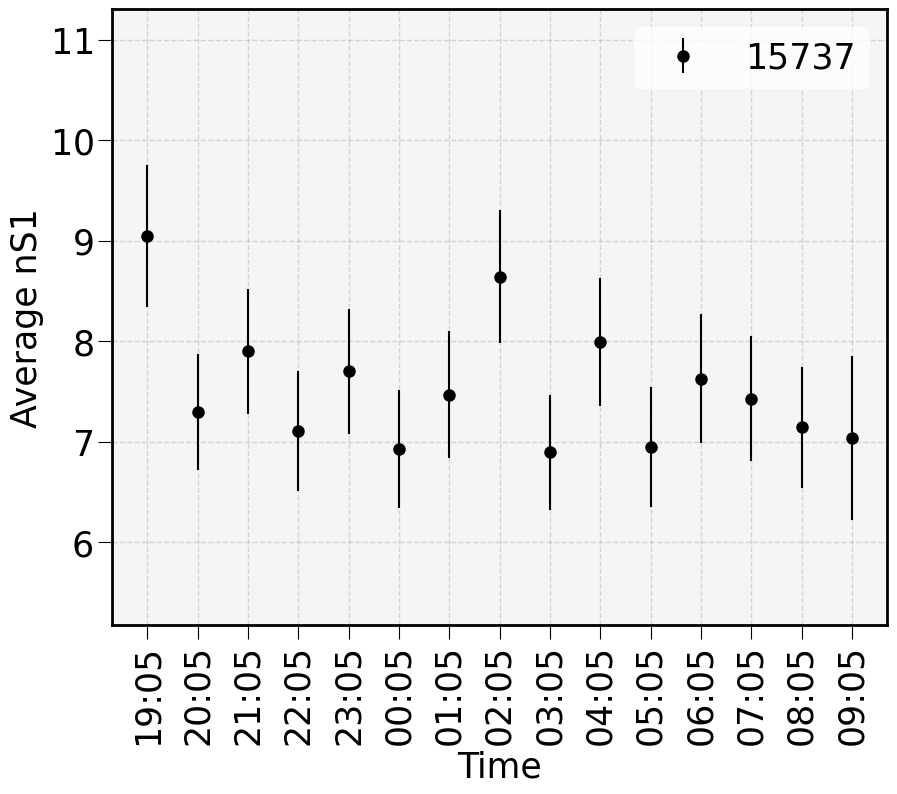

In [ ]:
mult_df = calculate_hourly_stats(HIGH_DF)

plt.errorbar( mult_df['time_cv'], mult_df['nS1_cv'], yerr=mult_df['nS1_err']
            , fmt='o', c='black', ecolor='black', elinewidth=1.5, label=RUN_NUMBER)

x_labels = [crudo.ut.epoch_converter(t, h=True) for t in mult_df['time_cv']]
plt.xticks(mult_df['time_cv'], x_labels, rotation=90)
plt.xlabel('Time')
plt.ylabel('Average nS1')
plt.ylim(mult_df['nS1_cv'].min()*0.75, mult_df['nS1_cv'].max()*1.25)
plt.legend()

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.show()